# VoxConverse Dataset Analysis
## Configuration optimale CUDA + Analyse multi-segments

Analyse complète du dataset VoxConverse avec :
- Configuration CUDA optimale (batch_size=32, num_workers=4, pin_memory=True)
- Segments multiples : 4s, 10s, 1min, 2min
- Audio display + Spectrogrammes + Mel + VAD/OSD
- Aucun filtrage du dataset (conservation de tous les segments)

In [1]:
# Import des bibliothèques requises
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
from pathlib import Path
import pandas as pd
from typing import Dict, List, Tuple
import ipywidgets as widgets
from IPython.display import display

# Import de la classe VoxConverse modifiée
sys.path.append('src')
from voxconverse_dataset import VoxConverseDataset, create_voxconverse_dataloaders

# Configuration pour les graphiques
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)

print("✅ Imports terminés")

✅ Imports terminés


In [2]:
# Configuration globale des paramètres
CONFIGS = {
    # Durées des segments à analyser
    'segment_durations': [4.0, 10.0, 60.0, 120.0],  # 4s, 10s, 1min, 2min
    
    # Configuration CUDA optimale
    'batch_size': 32,
    'num_workers': 4,
    'pin_memory': True,
    'persistent_workers': True,
    'prefetch_factor': 2,
    
    # Paramètres audio
    'sample_rate': 16000,
    'n_mels': 80,
    'hop_duration': 2.0,
    'max_speakers': 8,
    
    # Paramètres d'affichage
    'figsize': (18, 12),
    'dpi': 100,
    
    # Nombre d'échantillons à analyser par durée
    'samples_per_duration': 3
}

print("✅ Configuration globale définie")
print(f"📊 Durées à analyser: {CONFIGS['segment_durations']}")
print(f"🎯 Config CUDA: batch_size={CONFIGS['batch_size']}, workers={CONFIGS['num_workers']}")

✅ Configuration globale définie
📊 Durées à analyser: [4.0, 10.0, 60.0, 120.0]
🎯 Config CUDA: batch_size=32, workers=4


In [3]:
def analyze_segment(dataset, segment_idx, title="Segment Analysis"):
    """
    Fonction principale d'analyse d'un segment audio avec widget interactif.
    
    Args:
        dataset: Instance de VoxConverseDataset
        segment_idx: Index du segment à analyser
        title: Titre pour l'affichage
    """
    # Récupérer le segment
    sample = dataset[segment_idx]
    
    audio = sample['audio'].numpy()
    features = sample['features'].numpy()  # [n_mels, time]
    vad_labels = sample['vad_labels'].numpy()  # [time, speakers]
    osd_labels = sample['osd_labels'].numpy()  # [time]
    
    # Informations sur le segment
    duration = len(audio) / CONFIGS['sample_rate']
    conv_idx = sample['conv_idx']
    start_time = sample['start_time']
    
    print(f"\n🎵 {title}")
    print(f"   Conversation: {conv_idx}, Début: {start_time:.1f}s, Durée: {duration:.1f}s")
    print(f"   Audio shape: {audio.shape}, Features shape: {features.shape}")
    print(f"   Speakers actifs: {vad_labels.sum(axis=0)}")
    print(f"   Overlap frames: {osd_labels.sum():.0f}/{len(osd_labels)} ({osd_labels.mean()*100:.1f}%)")
    
    # Créer la figure
    fig, axes = plt.subplots(4, 1, figsize=CONFIGS['figsize'], dpi=CONFIGS['dpi'])
    
    # 1. Forme d'onde audio
    time_axis = np.linspace(0, duration, len(audio))
    axes[0].plot(time_axis, audio, color='navy', alpha=0.7)
    axes[0].set_title('Forme d\'onde audio', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Spectrogramme Mel
    time_frames = np.linspace(0, duration, features.shape[1])
    mel_db = librosa.amplitude_to_db(features, ref=np.max)
    im1 = axes[1].imshow(mel_db, aspect='auto', origin='lower', 
                        extent=[0, duration, 0, CONFIGS['n_mels']], 
                        cmap='viridis')
    axes[1].set_title('Spectrogramme Mel (dB)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Mel Bins')
    plt.colorbar(im1, ax=axes[1], label='dB')
    
    # 3. Labels VAD (Voice Activity Detection)
    vad_time = np.linspace(0, duration, vad_labels.shape[0])
    im2 = axes[2].imshow(vad_labels.T, aspect='auto', origin='lower',
                        extent=[0, duration, 0, CONFIGS['max_speakers']], 
                        cmap='Reds', vmin=0, vmax=1)
    axes[2].set_title('VAD - Activité par Speaker', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Speaker ID')
    plt.colorbar(im2, ax=axes[2], label='Activité')
    
    # 4. Labels OSD (Overlap Speech Detection)
    axes[3].fill_between(vad_time, 0, osd_labels, alpha=0.7, color='orange', label='Overlap')
    axes[3].plot(vad_time, osd_labels, color='red', linewidth=2)
    axes[3].set_title('OSD - Détection de Chevauchement', fontsize=14, fontweight='bold')
    axes[3].set_ylabel('Overlap')
    axes[3].set_xlabel('Temps (s)')
    axes[3].set_ylim(0, 1.1)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Widget interactif pour l'audio
    print("🔊 Lecteur audio interactif:")
    
    # Créer les widgets
    play_button = widgets.Button(
        description='▶️ Play',
        disabled=False,
        button_style='success',
        tooltip='Lire l\'audio',
        icon='play'
    )
    
    pause_button = widgets.Button(
        description='⏸️ Pause',
        disabled=False,
        button_style='warning',
        tooltip='Pause l\'audio',
        icon='pause'
    )
    
    volume_slider = widgets.FloatSlider(
        value=0.5,
        min=0.0,
        max=1.0,
        step=0.1,
        description='Volume:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.1f',
    )
    
    speed_slider = widgets.FloatSlider(
        value=1.0,
        min=0.5,
        max=2.0,
        step=0.1,
        description='Vitesse:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.1f',
    )
    
    # Info widget
    info_widget = widgets.HTML(
        value=f"""
        <div style="padding: 10px; border: 1px solid #ddd; border-radius: 5px; background-color: #f9f9f9;">
            <b>📊 Informations Audio:</b><br>
            • Durée: {duration:.2f}s<br>
            • Sample Rate: {CONFIGS['sample_rate']} Hz<br>
            • Taille: {len(audio)} échantillons<br>
            • Speakers actifs: {(vad_labels.sum(axis=0) > 0).sum()}<br>
            • Chevauchement: {osd_labels.mean()*100:.1f}%
        </div>
        """
    )
    
    # Widget d'affichage audio HTML5
    audio_widget = widgets.HTML(
        value=f"""
        <audio controls style="width: 100%;">
            <source src="data:audio/wav;base64,{ipd.Audio(audio, rate=CONFIGS['sample_rate'])._repr_html_().split('src="')[1].split('"')[0].split(',')[1]}" type="audio/wav">
            Votre navigateur ne supporte pas l'élément audio.
        </audio>
        """
    )
    
    # Organiser les widgets
    controls_box = widgets.HBox([play_button, pause_button])
    sliders_box = widgets.VBox([volume_slider, speed_slider])
    controls_and_sliders = widgets.HBox([controls_box, sliders_box])
    
    # Widget principal
    audio_interface = widgets.VBox([
        info_widget,
        audio_widget,
        controls_and_sliders
    ])
    
    # Fonctions des boutons (simulation car HTML5 audio est géré par le navigateur)
    def on_play_clicked(b):
        with play_button.hold_sync():
            play_button.description = '⏸️ Playing...'
            play_button.button_style = 'warning'
    
    def on_pause_clicked(b):
        with pause_button.hold_sync():
            play_button.description = '▶️ Play'
            play_button.button_style = 'success'
    
    play_button.on_click(on_play_clicked)
    pause_button.on_click(on_pause_clicked)
    
    # Afficher le widget
    display(audio_interface)
    
    return sample

print("✅ Fonction d'analyse avec widget interactif définie")

✅ Fonction d'analyse avec widget interactif définie


## Analyse par Durée de Segment

Analyse des différentes durées configurées avec recherche automatique d'échantillons intéressants (multi-speakers + overlap).

In [4]:
# Analyse pour chaque durée de segment
datasets = {}
interesting_samples = {}

for duration in CONFIGS['segment_durations']:
    print(f"\n{'='*60}")
    print(f"🎯 ANALYSE SEGMENTS {duration}s")
    print(f"{'='*60}")
    
    # Créer le dataset pour cette durée
    print(f"📂 Chargement dataset (segment_duration={duration}s)...")
    dataset = VoxConverseDataset(
        split='dev',
        segment_duration=duration,
        hop_duration=CONFIGS['hop_duration'],
        sample_rate=CONFIGS['sample_rate'],
        n_mels=CONFIGS['n_mels'],
        max_speakers=CONFIGS['max_speakers']
    )
    datasets[duration] = dataset
    
    print(f"✅ Dataset chargé: {len(dataset)} segments")
    
    # Recherche d'échantillons intéressants (multi-speakers + overlap)
    print("🔍 Recherche d'échantillons intéressants...")
    interesting_indices = []
    
    for i in range(min(len(dataset), 500)):  # Parcourir les premiers 500 segments
        sample = dataset[i]
        vad_labels = sample['vad_labels'].numpy()
        osd_labels = sample['osd_labels'].numpy()
        
        # Critères d'intérêt:
        num_active_speakers = (vad_labels.sum(axis=0) > 0).sum()  # Nb speakers actifs
        overlap_ratio = osd_labels.mean()  # Ratio de chevauchement
        total_activity = vad_labels.sum()  # Activité totale
        
        # Score d'intérêt
        interest_score = (
            num_active_speakers * 2 +  # Bonus multi-speakers
            overlap_ratio * 10 +       # Bonus overlap
            min(total_activity / len(vad_labels), 1) * 3  # Bonus activité
        )
        
        if interest_score > 4 and len(interesting_indices) < CONFIGS['samples_per_duration']:
            interesting_indices.append((i, interest_score, num_active_speakers, overlap_ratio))
    
    # Trier par score d'intérêt
    interesting_indices.sort(key=lambda x: x[1], reverse=True)
    interesting_samples[duration] = interesting_indices[:CONFIGS['samples_per_duration']]
    
    print(f"🎯 Échantillons intéressants trouvés:")
    for idx, (seg_idx, score, speakers, overlap) in enumerate(interesting_samples[duration]):
        print(f"   {idx+1}. Segment {seg_idx}: score={score:.1f}, speakers={speakers}, overlap={overlap:.1%}")

print(f"\n✅ Analyse terminée pour toutes les durées")


🎯 ANALYSE SEGMENTS 4.0s
📂 Chargement dataset (segment_duration=4.0s)...
Loading VoxConverse dev split...
  Processing conversation 1/216
  Processing conversation 1/216
  Processing conversation 51/216
  Processing conversation 51/216
  Processing conversation 101/216
  Processing conversation 101/216
  Processing conversation 151/216
  Processing conversation 151/216
  Processing conversation 201/216
  Processing conversation 201/216
✅ Prepared 36205 segments from 216 conversations
✅ Dataset chargé: 36205 segments
🔍 Recherche d'échantillons intéressants...
✅ Prepared 36205 segments from 216 conversations
✅ Dataset chargé: 36205 segments
🔍 Recherche d'échantillons intéressants...
🎯 Échantillons intéressants trouvés:
   1. Segment 1: score=5.0, speakers=1, overlap=0.0%
   2. Segment 2: score=5.0, speakers=1, overlap=0.0%
   3. Segment 0: score=4.9, speakers=1, overlap=0.0%

🎯 ANALYSE SEGMENTS 10.0s
📂 Chargement dataset (segment_duration=10.0s)...
Loading VoxConverse dev split...
🎯 Écha

## Visualisation des Échantillons Intéressants

Analyse détaillée des segments les plus intéressants pour chaque durée configurée.


🎵 SEGMENTS 4.0s - ÉCHANTILLONS INTÉRESSANTS

🎵 Segment 4.0s #1 (idx=1, score=5.0, 1 speakers, 0.0% overlap)
   Conversation: 0, Début: 2.0s, Durée: 4.0s
   Audio shape: (64000,), Features shape: (80, 200)
   Speakers actifs: [  0. 200.   0.   0.   0.   0.   0.   0.]
   Overlap frames: 0/200 (0.0%)


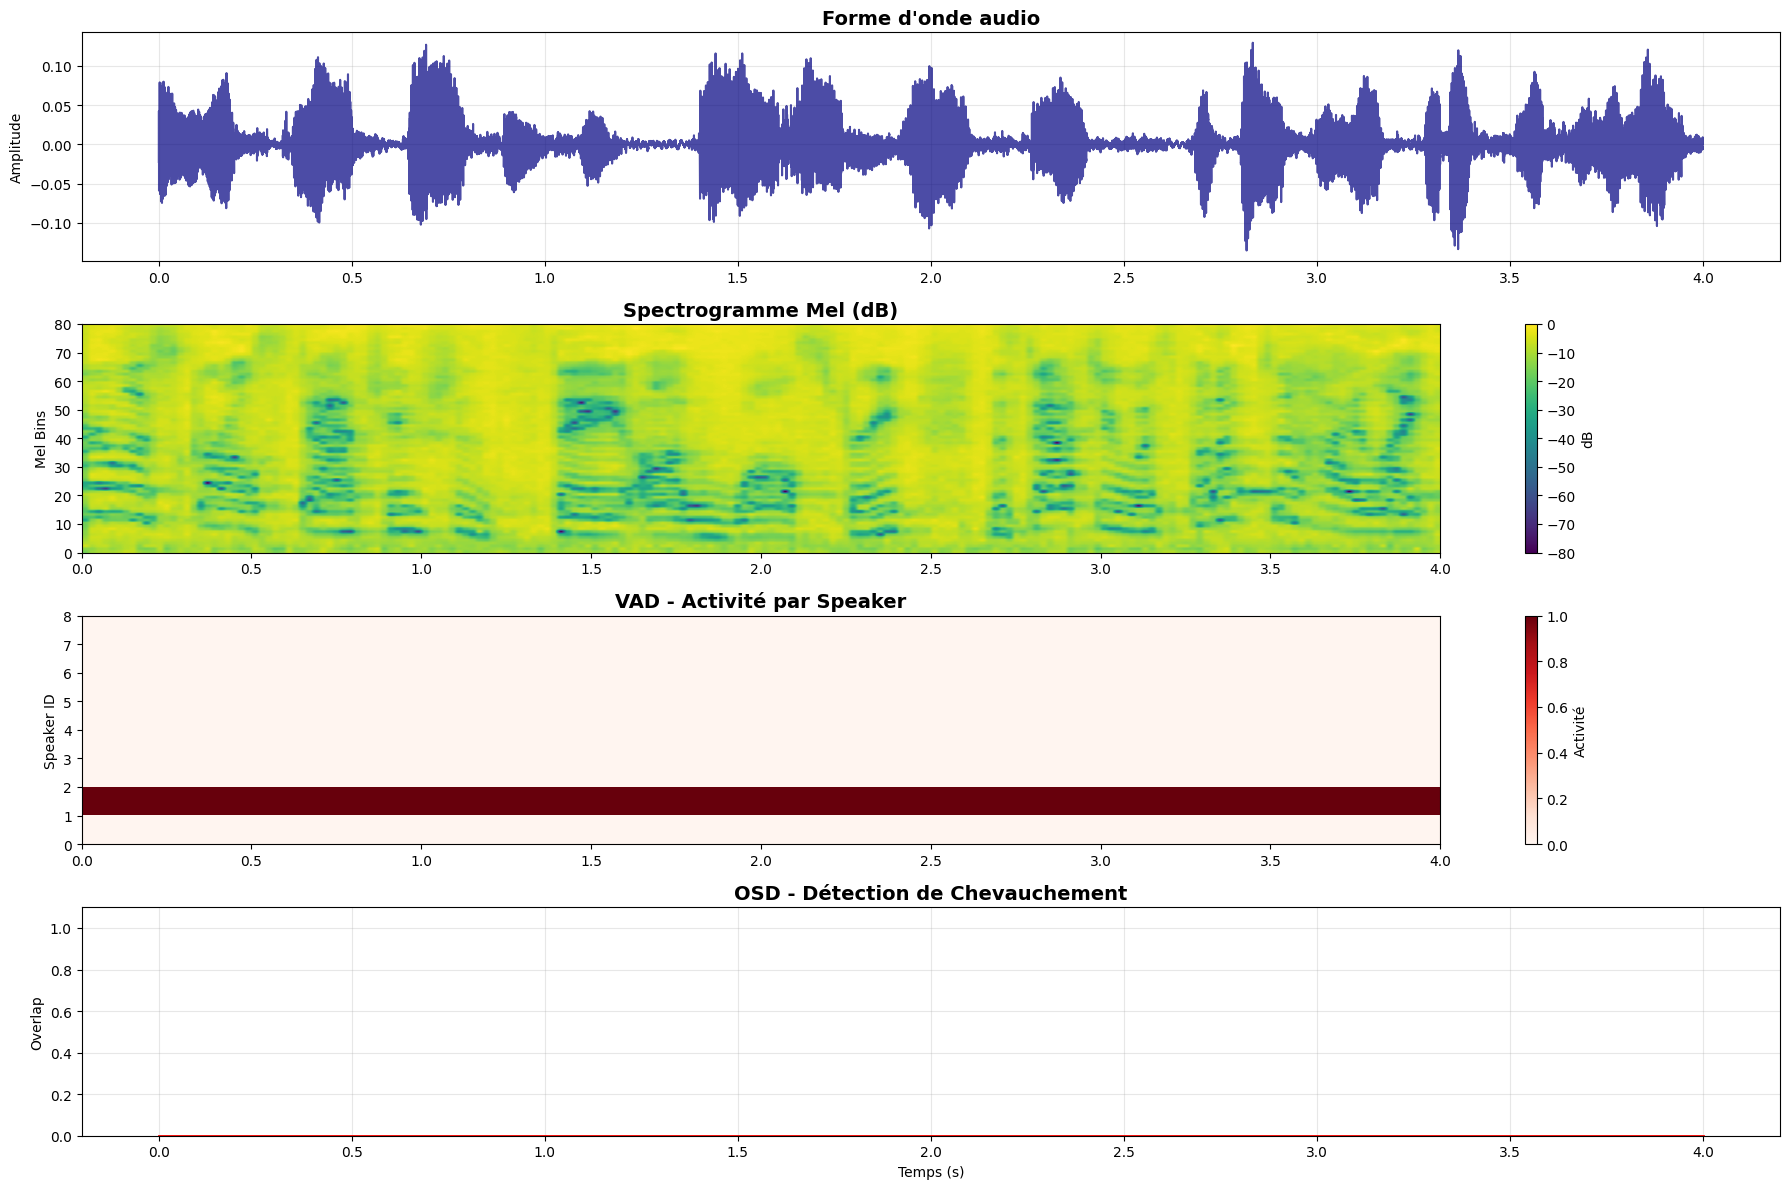

🔊 Lecteur audio interactif:



🎵 Segment 4.0s #2 (idx=2, score=5.0, 1 speakers, 0.0% overlap)
   Conversation: 0, Début: 4.0s, Durée: 4.0s
   Audio shape: (64000,), Features shape: (80, 200)
   Speakers actifs: [  0. 200.   0.   0.   0.   0.   0.   0.]
   Overlap frames: 0/200 (0.0%)


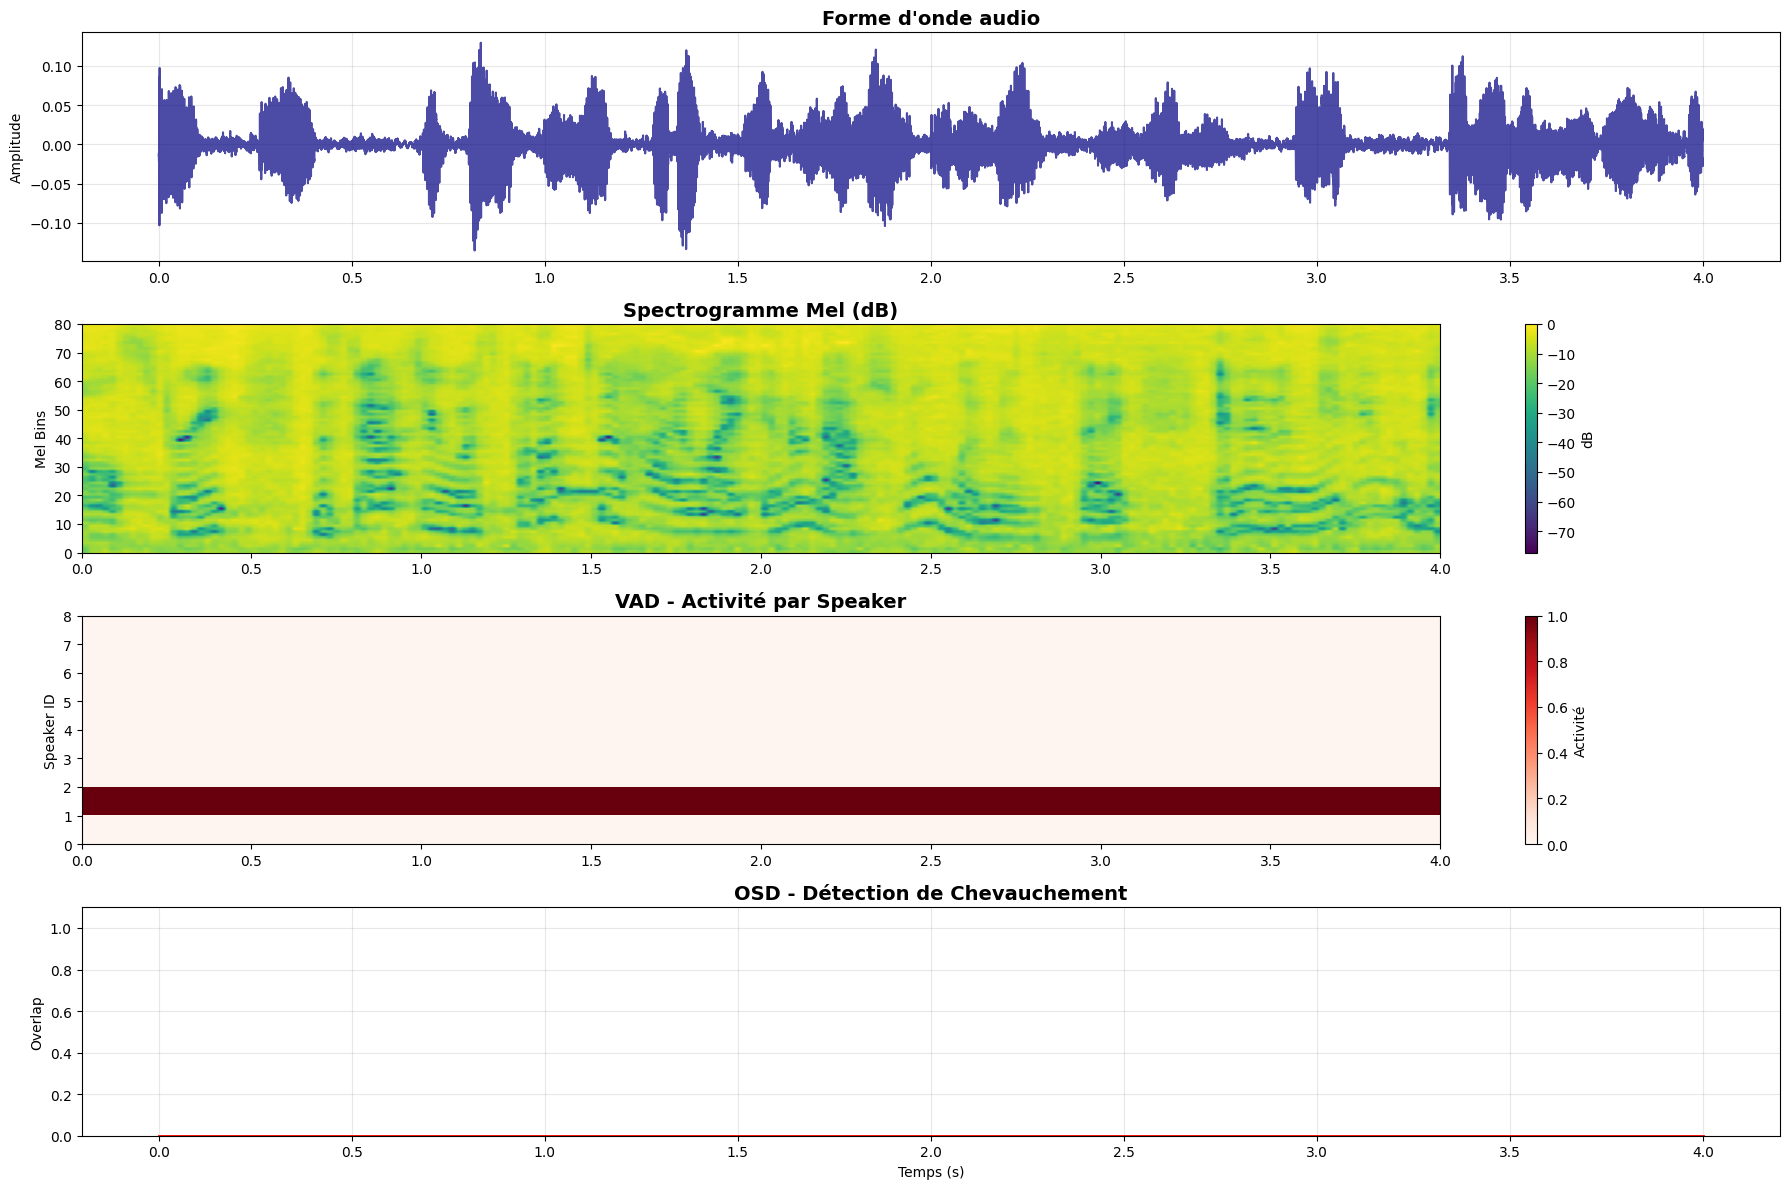

🔊 Lecteur audio interactif:



🎵 Segment 4.0s #3 (idx=0, score=4.9, 1 speakers, 0.0% overlap)
   Conversation: 0, Début: 0.0s, Durée: 4.0s
   Audio shape: (64000,), Features shape: (80, 200)
   Speakers actifs: [  0. 192.   0.   0.   0.   0.   0.   0.]
   Overlap frames: 0/200 (0.0%)


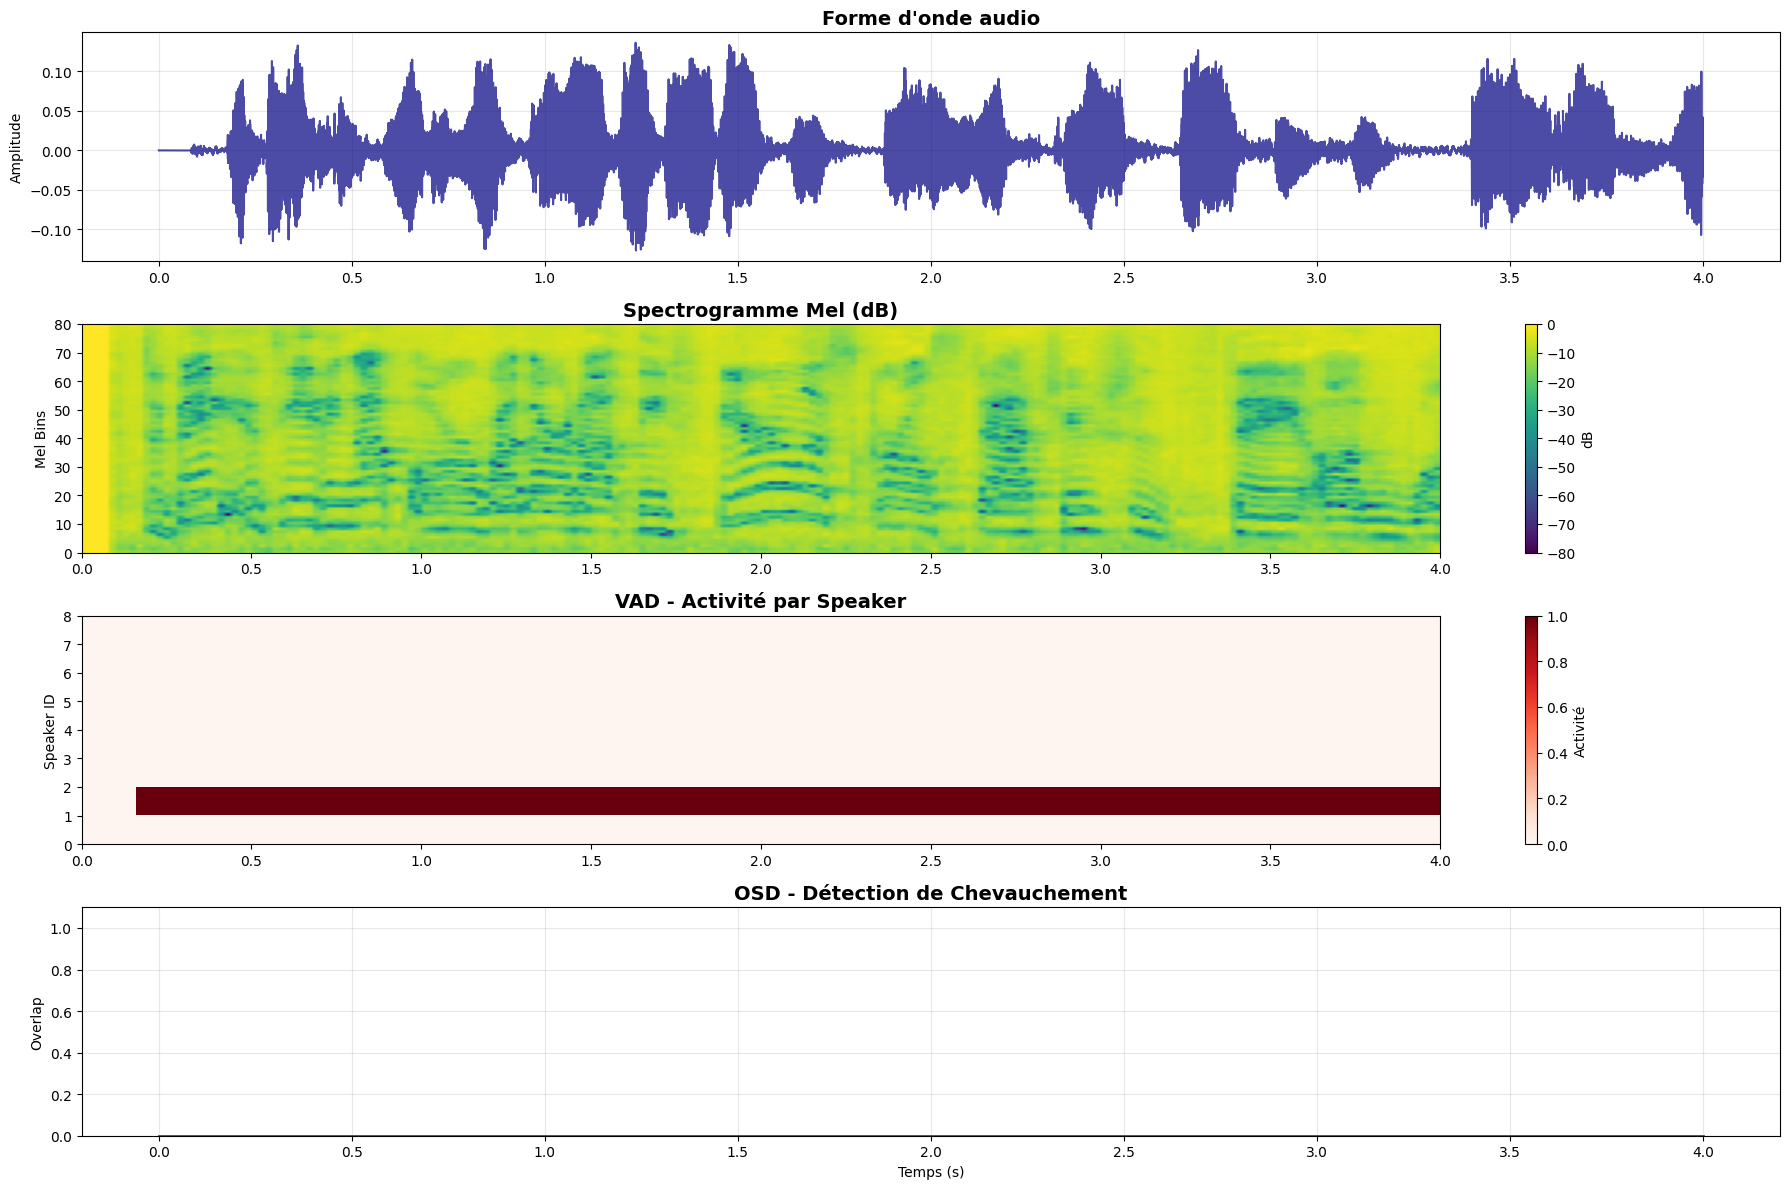

🔊 Lecteur audio interactif:



🎵 SEGMENTS 10.0s - ÉCHANTILLONS INTÉRESSANTS

🎵 Segment 10.0s #1 (idx=1, score=5.0, 1 speakers, 0.0% overlap)
   Conversation: 0, Début: 2.0s, Durée: 10.0s
   Audio shape: (160000,), Features shape: (80, 500)
   Speakers actifs: [  0. 500.   0.   0.   0.   0.   0.   0.]
   Overlap frames: 0/500 (0.0%)


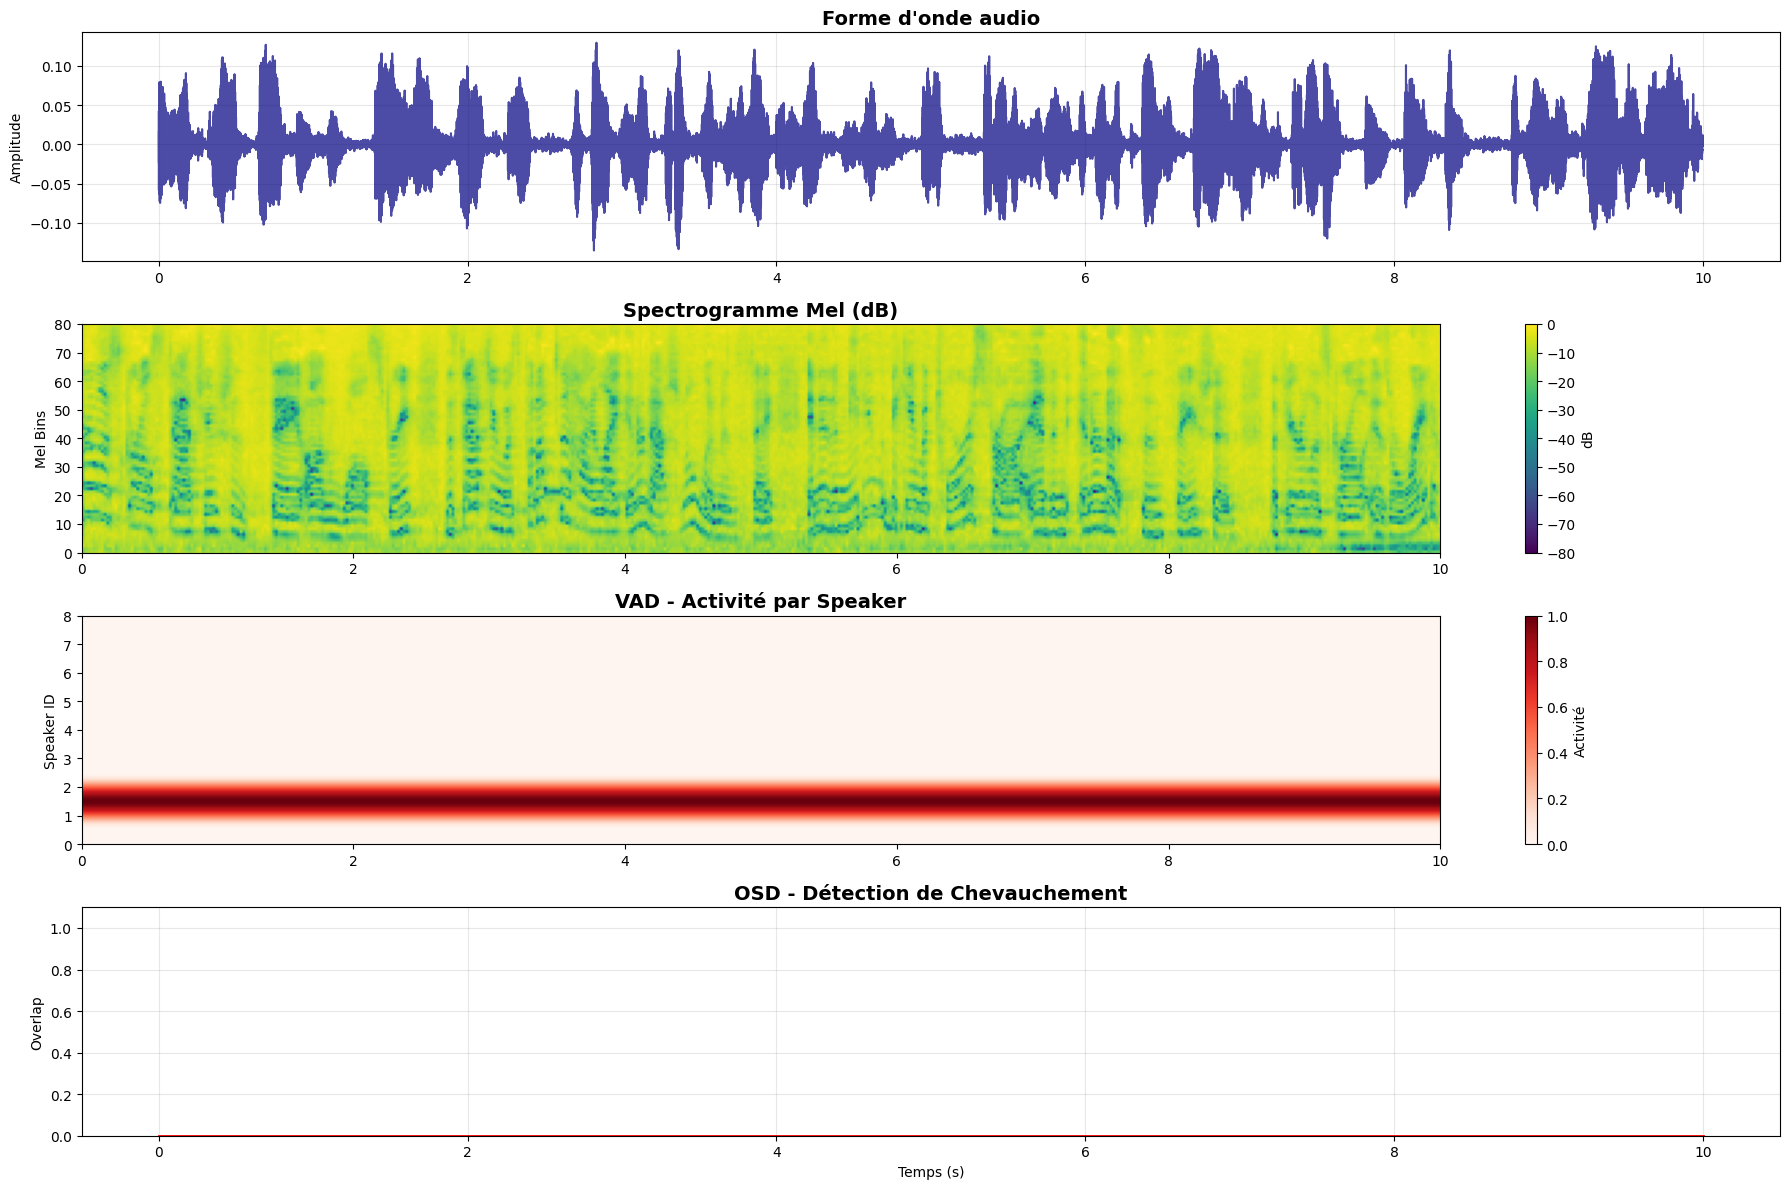

🔊 Lecteur audio interactif:



🎵 Segment 10.0s #2 (idx=2, score=5.0, 1 speakers, 0.0% overlap)
   Conversation: 0, Début: 4.0s, Durée: 10.0s
   Audio shape: (160000,), Features shape: (80, 500)
   Speakers actifs: [  0. 500.   0.   0.   0.   0.   0.   0.]
   Overlap frames: 0/500 (0.0%)


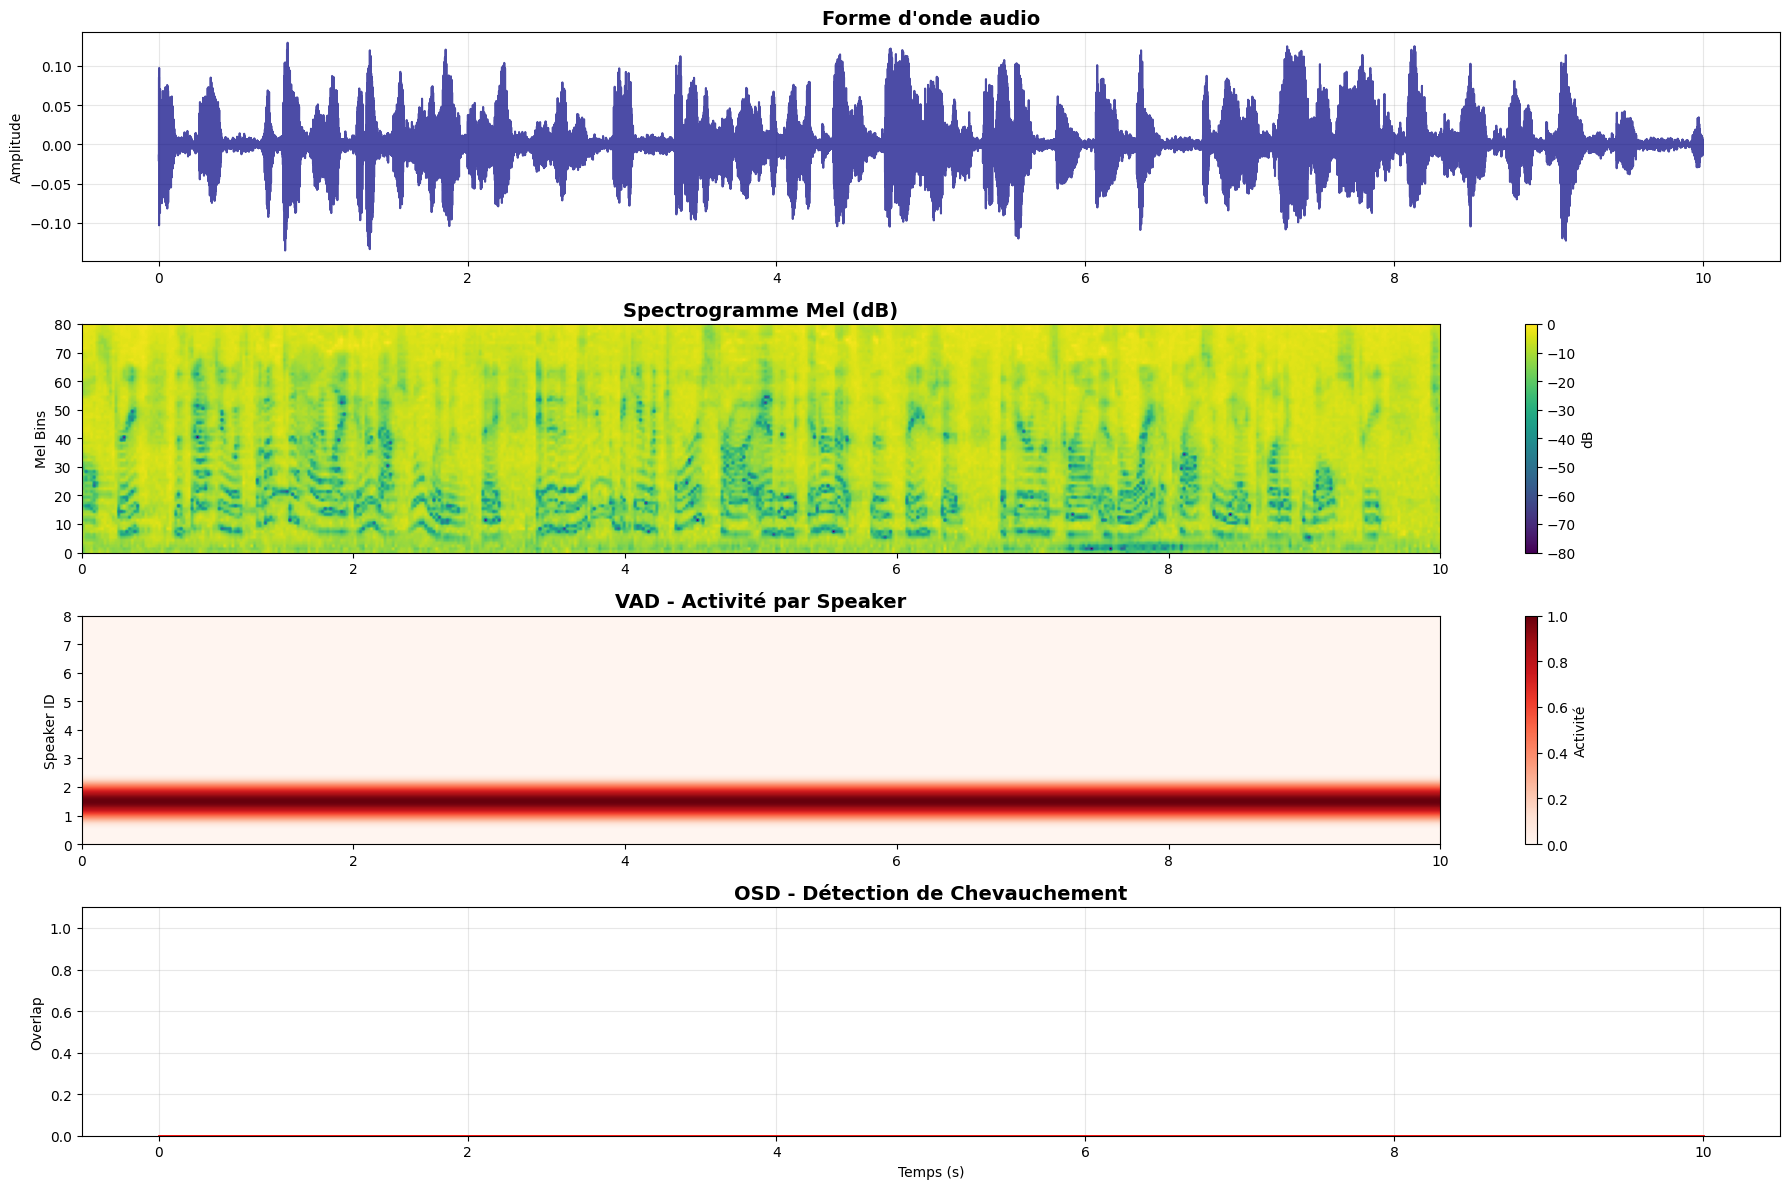

🔊 Lecteur audio interactif:



🎵 Segment 10.0s #3 (idx=0, score=5.0, 1 speakers, 0.0% overlap)
   Conversation: 0, Début: 0.0s, Durée: 10.0s
   Audio shape: (160000,), Features shape: (80, 500)
   Speakers actifs: [  0. 492.   0.   0.   0.   0.   0.   0.]
   Overlap frames: 0/500 (0.0%)


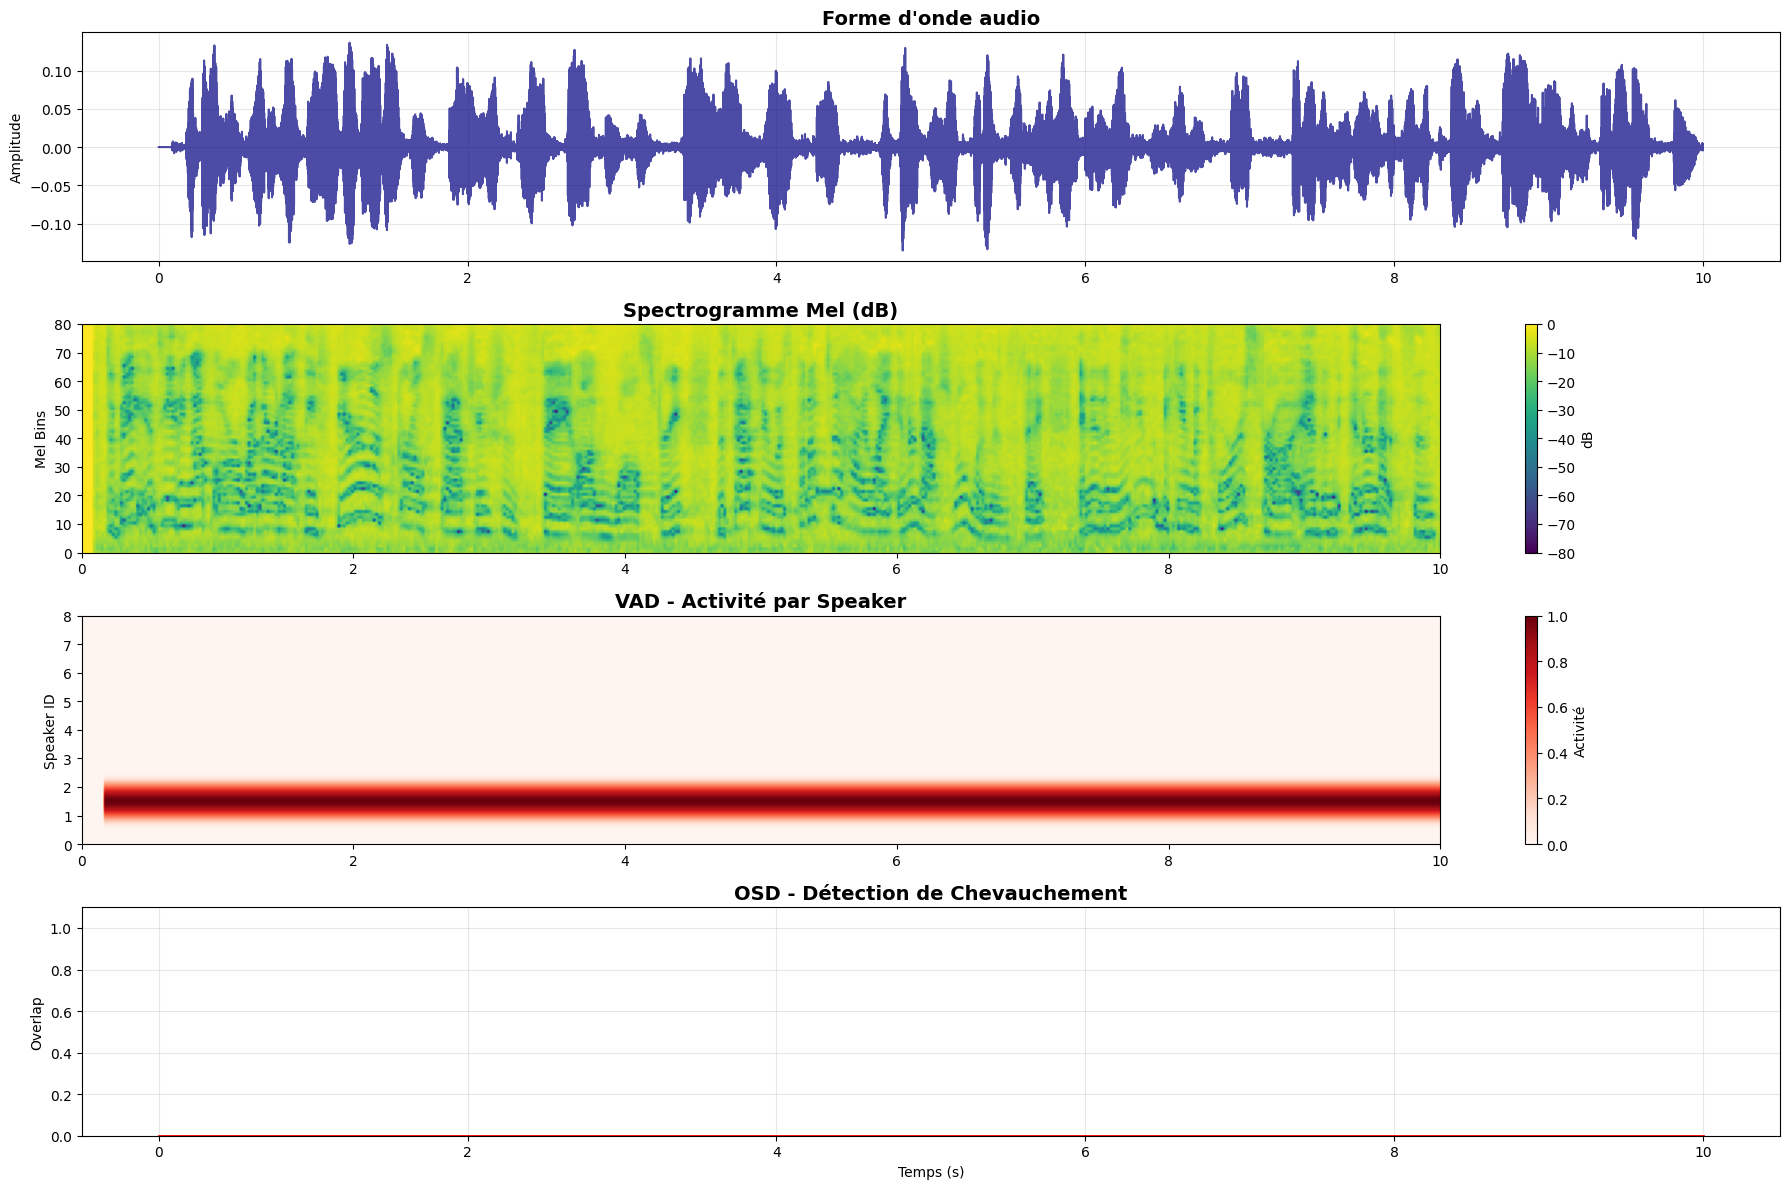

🔊 Lecteur audio interactif:



🎵 SEGMENTS 60.0s - ÉCHANTILLONS INTÉRESSANTS

🎵 Segment 60.0s #1 (idx=1, score=7.0, 2 speakers, 0.0% overlap)
   Conversation: 0, Début: 2.0s, Durée: 60.0s
   Audio shape: (960000,), Features shape: (80, 3000)
   Speakers actifs: [ 382. 2580.    0.    0.    0.    0.    0.    0.]
   Overlap frames: 0/3000 (0.0%)


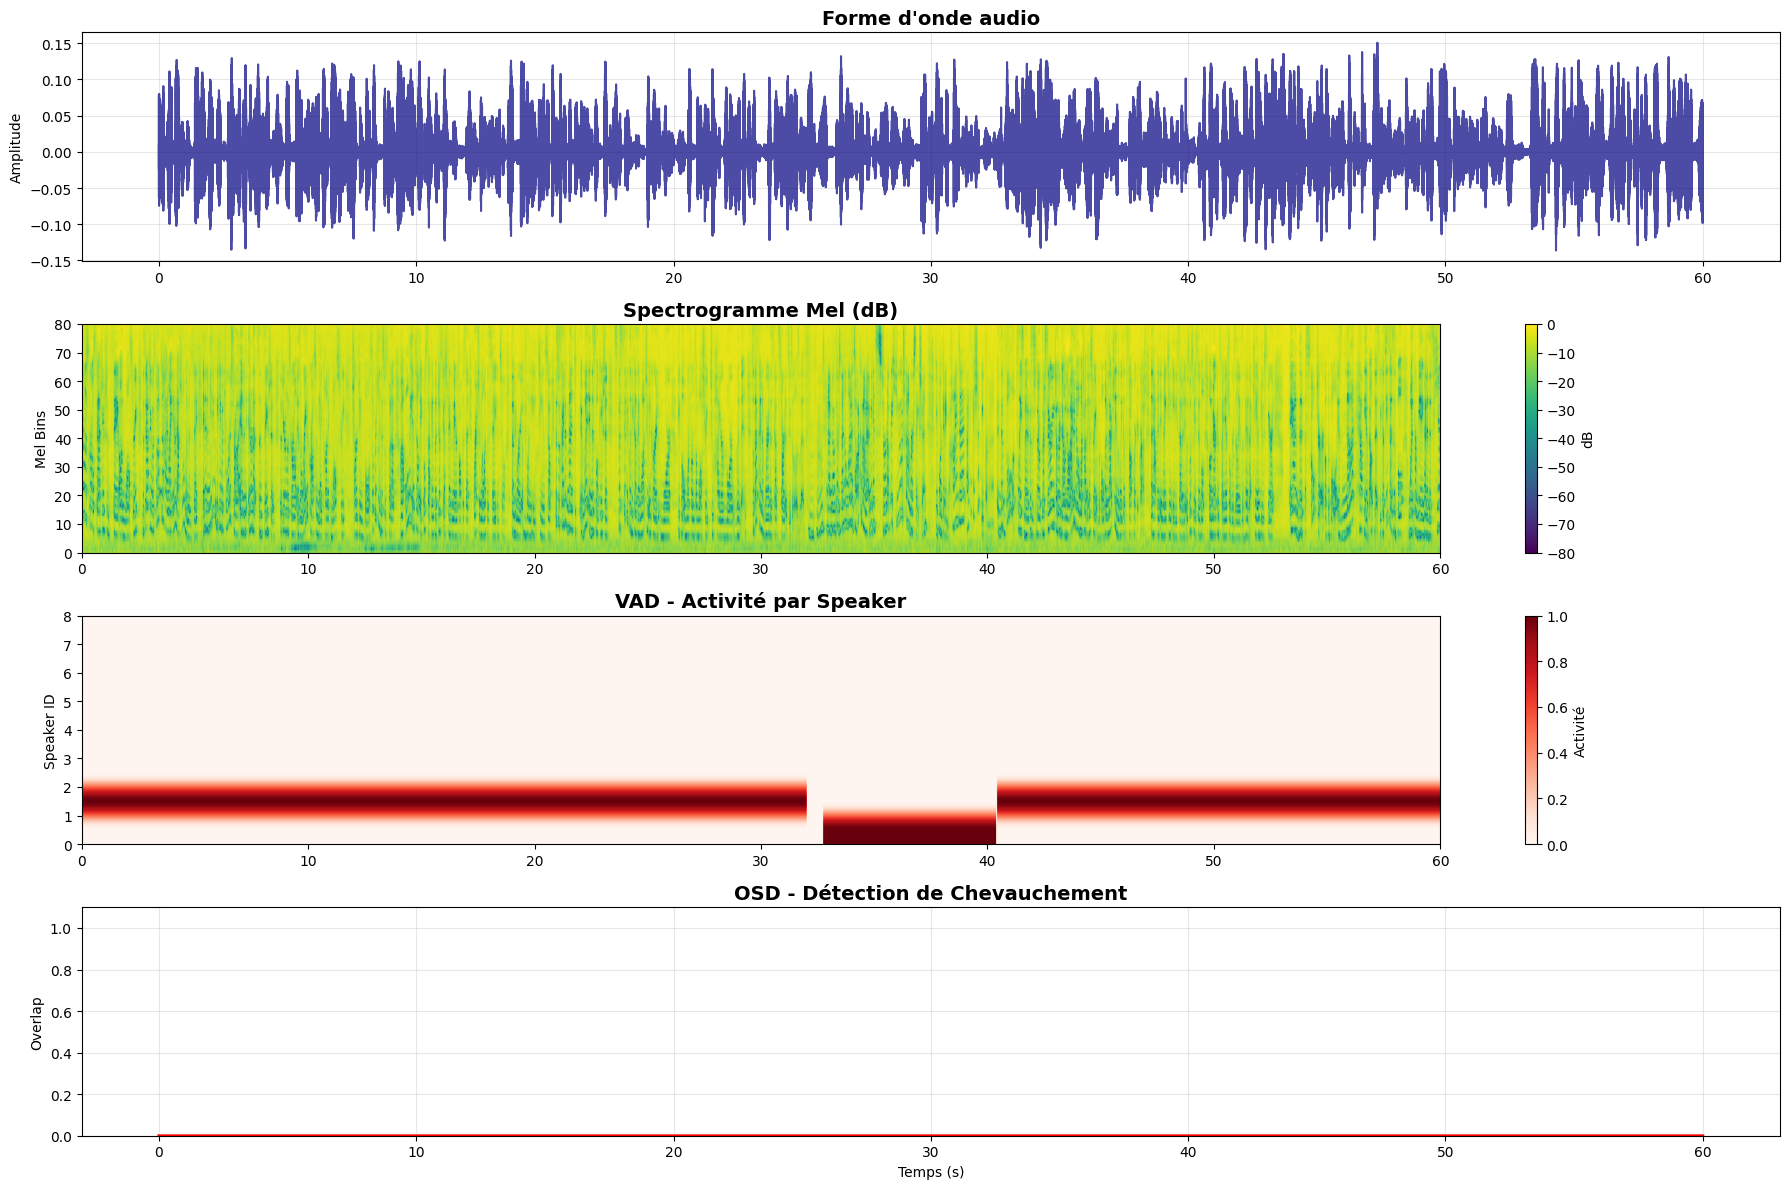

🔊 Lecteur audio interactif:



🎵 Segment 60.0s #2 (idx=2, score=7.0, 2 speakers, 0.0% overlap)
   Conversation: 0, Début: 4.0s, Durée: 60.0s
   Audio shape: (960000,), Features shape: (80, 3000)
   Speakers actifs: [ 382. 2580.    0.    0.    0.    0.    0.    0.]
   Overlap frames: 0/3000 (0.0%)


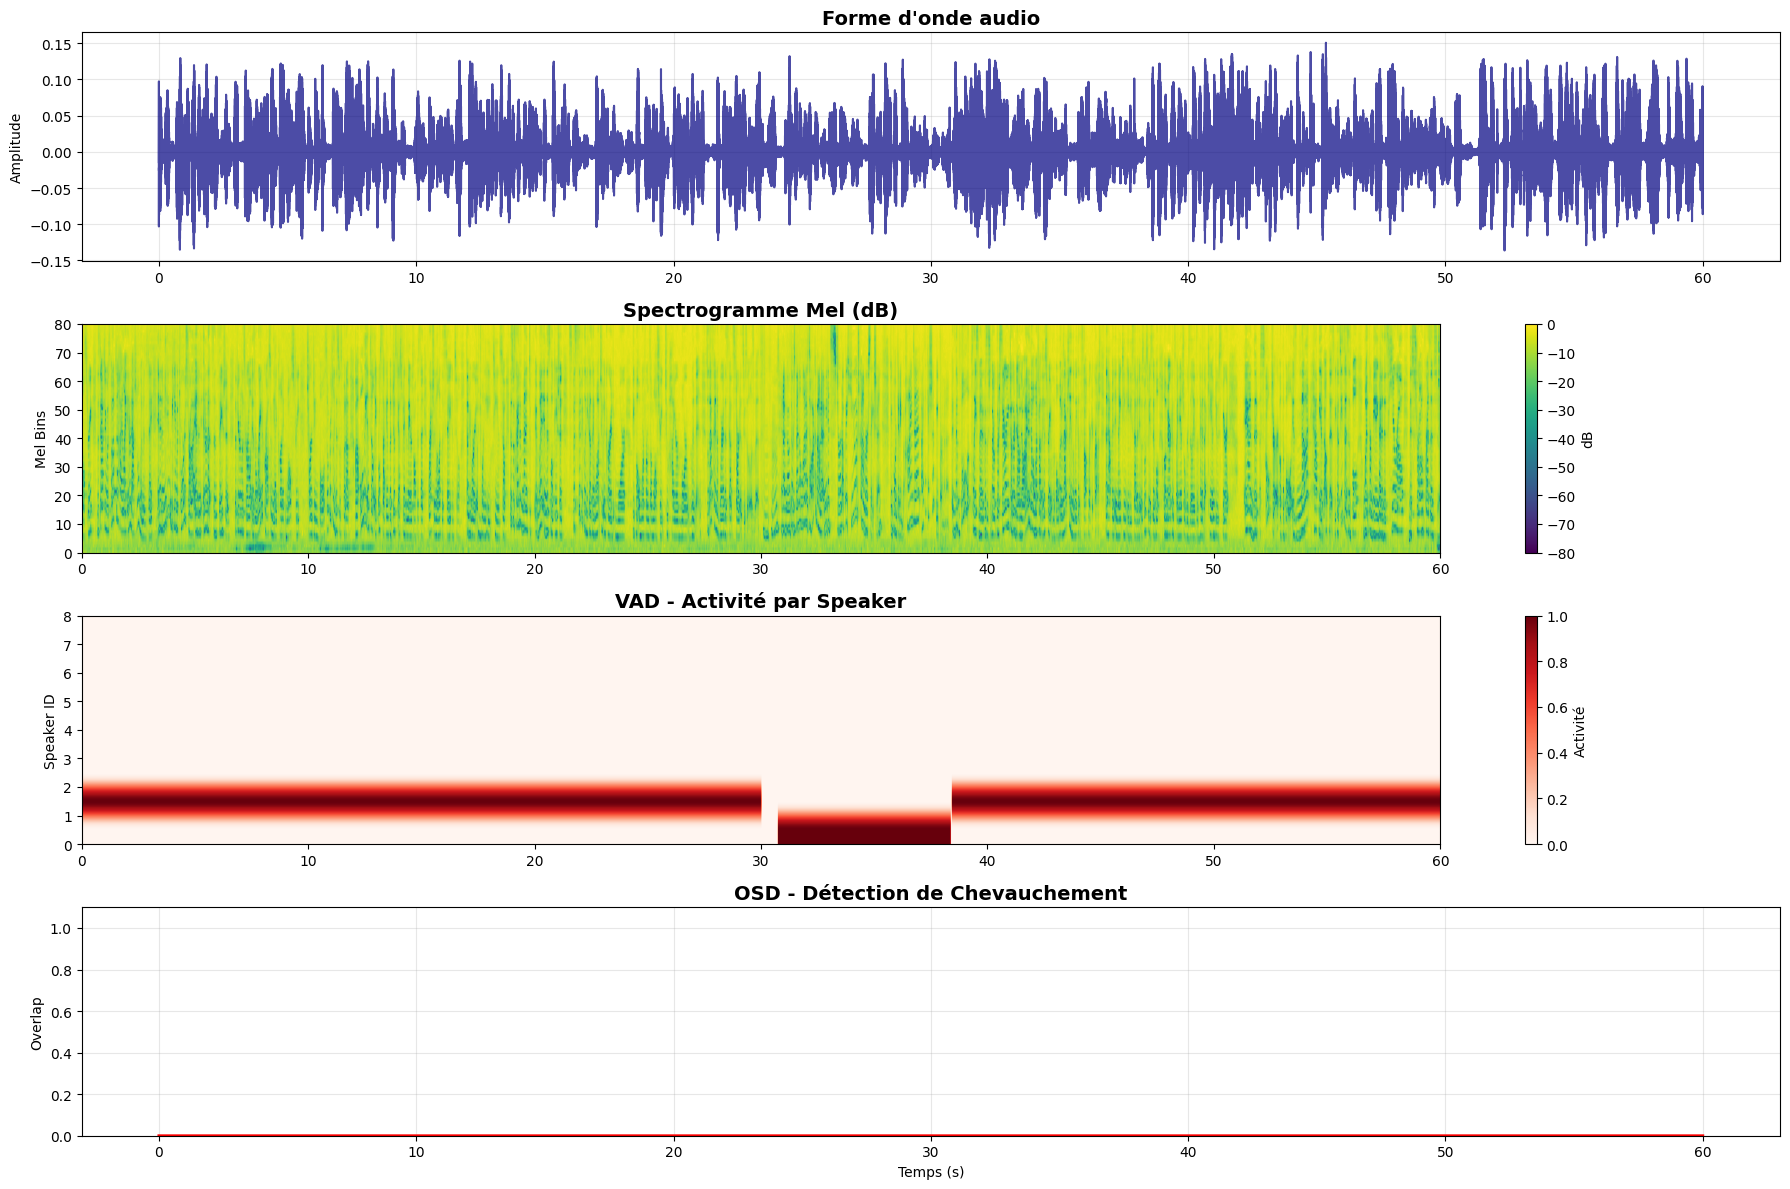

🔊 Lecteur audio interactif:



🎵 Segment 60.0s #3 (idx=0, score=7.0, 2 speakers, 0.0% overlap)
   Conversation: 0, Début: 0.0s, Durée: 60.0s
   Audio shape: (960000,), Features shape: (80, 3000)
   Speakers actifs: [ 382. 2572.    0.    0.    0.    0.    0.    0.]
   Overlap frames: 0/3000 (0.0%)


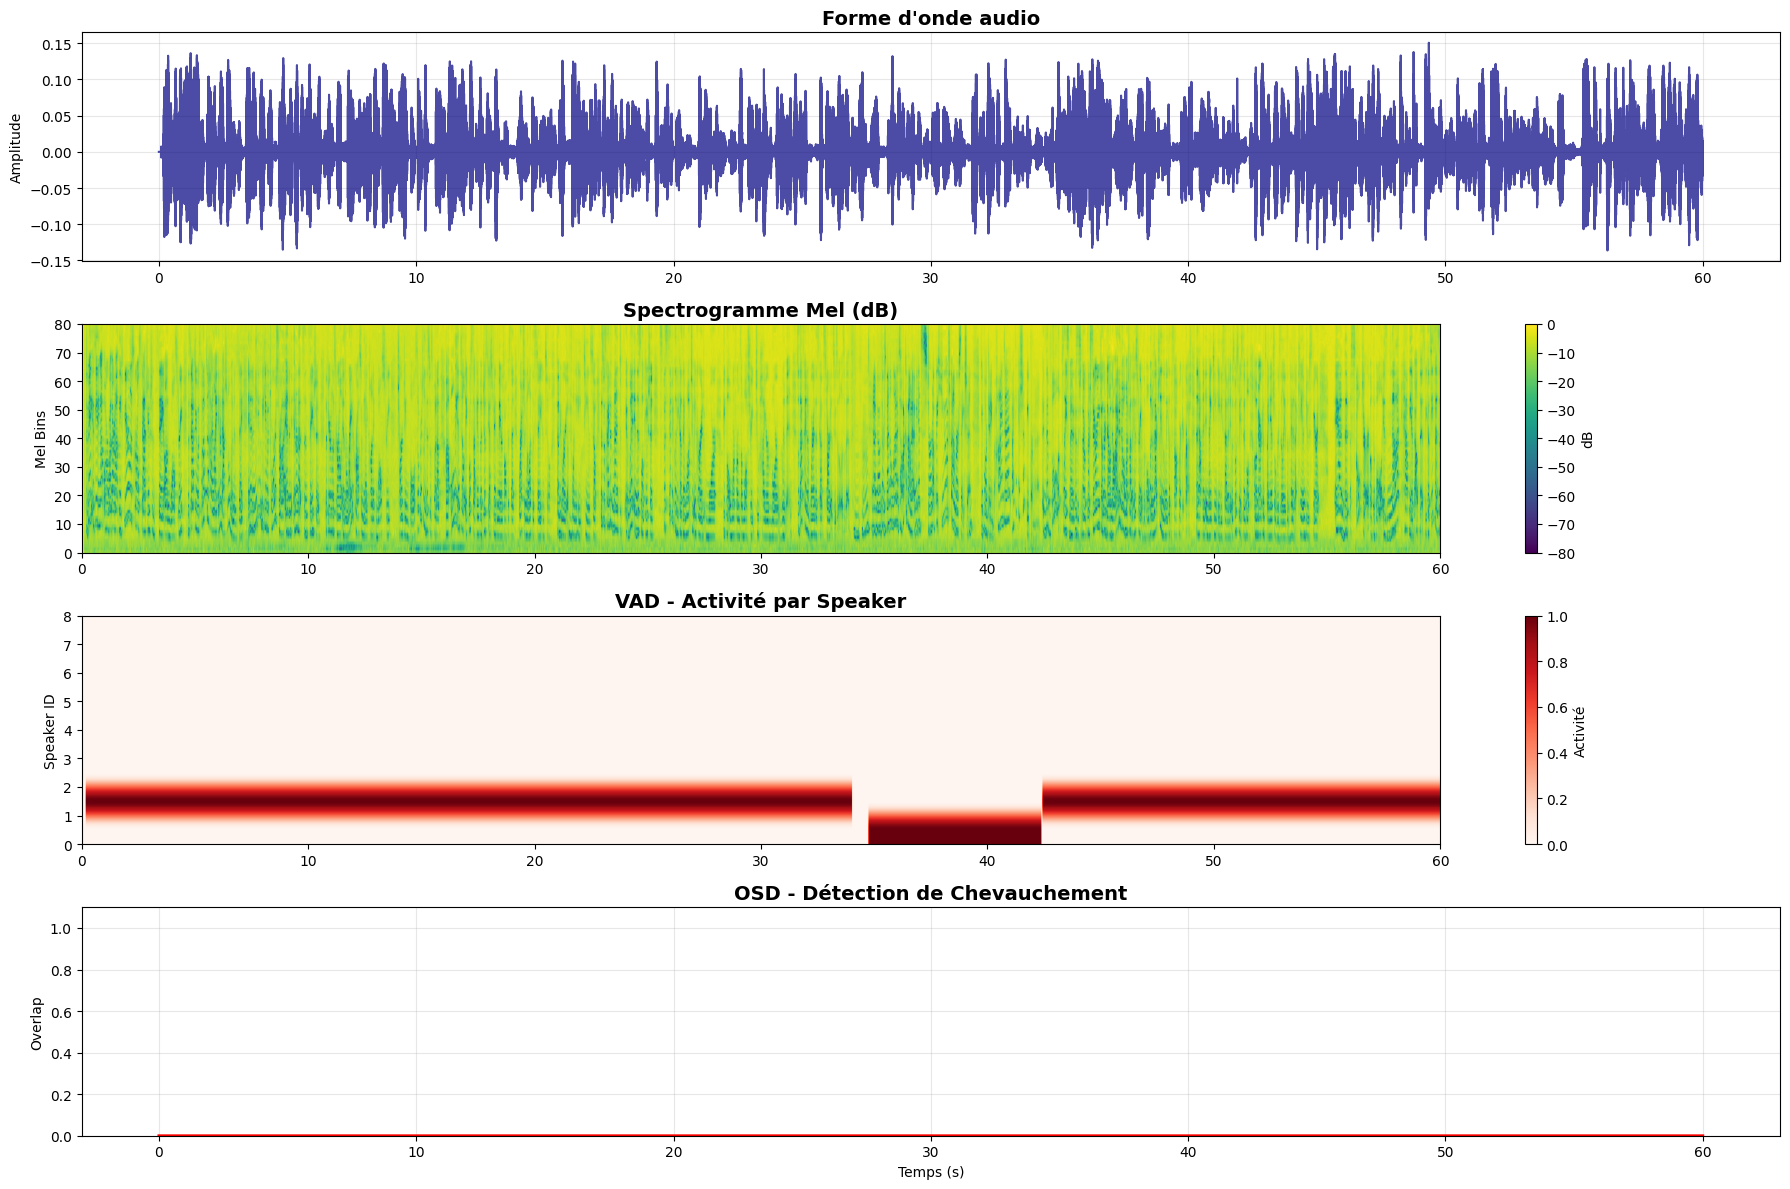

🔊 Lecteur audio interactif:



🎵 SEGMENTS 120.0s - ÉCHANTILLONS INTÉRESSANTS

🎵 Segment 120.0s #1 (idx=0, score=11.3, 4 speakers, 3.1% overlap)
   Conversation: 0, Début: 0.0s, Durée: 120.0s
   Audio shape: (1920000,), Features shape: (80, 6000)
   Speakers actifs: [ 604. 2914.  986. 1628.    0.    0.    0.    0.]
   Overlap frames: 183/6000 (3.0%)


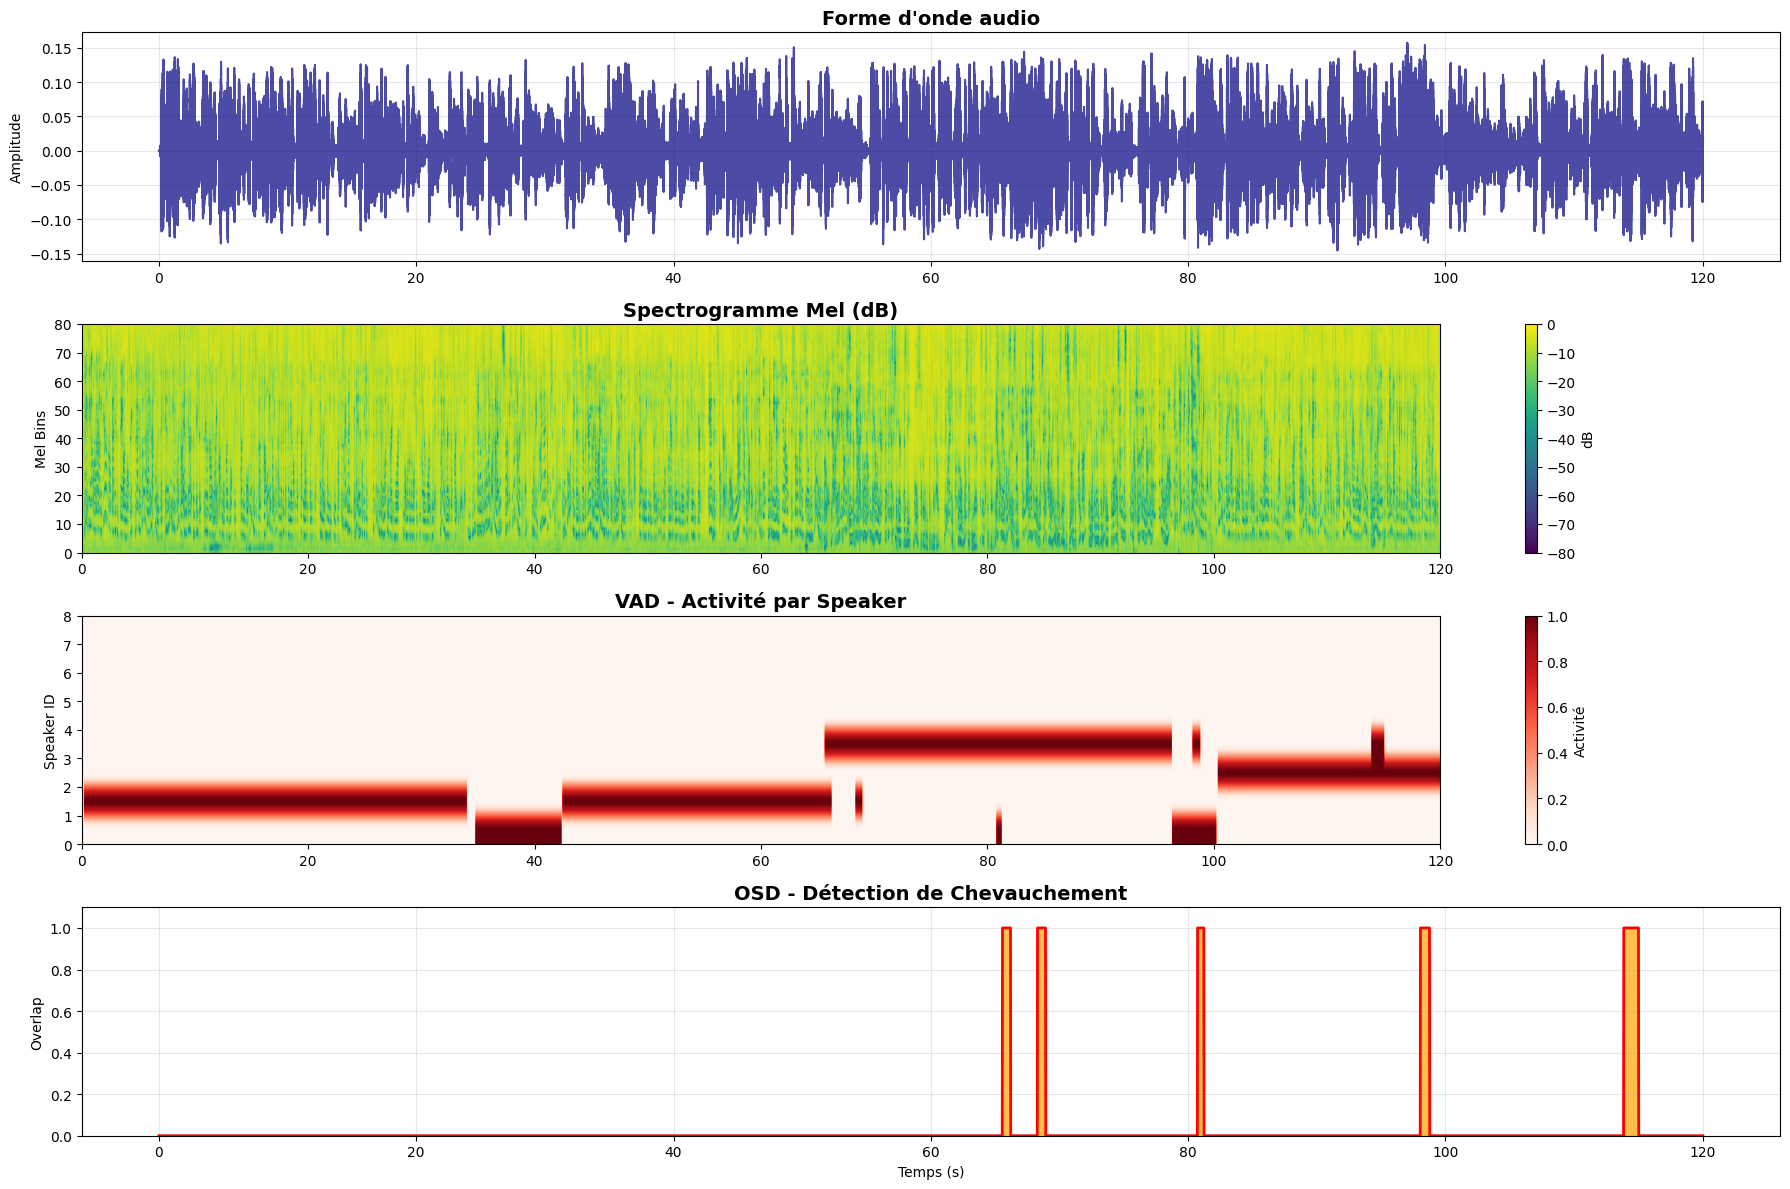

🔊 Lecteur audio interactif:



🎵 Segment 120.0s #2 (idx=1, score=11.3, 4 speakers, 3.1% overlap)
   Conversation: 0, Début: 2.0s, Durée: 120.0s
   Audio shape: (1920000,), Features shape: (80, 6000)
   Speakers actifs: [ 604. 2822. 1086. 1628.    0.    0.    0.    0.]
   Overlap frames: 183/6000 (3.0%)


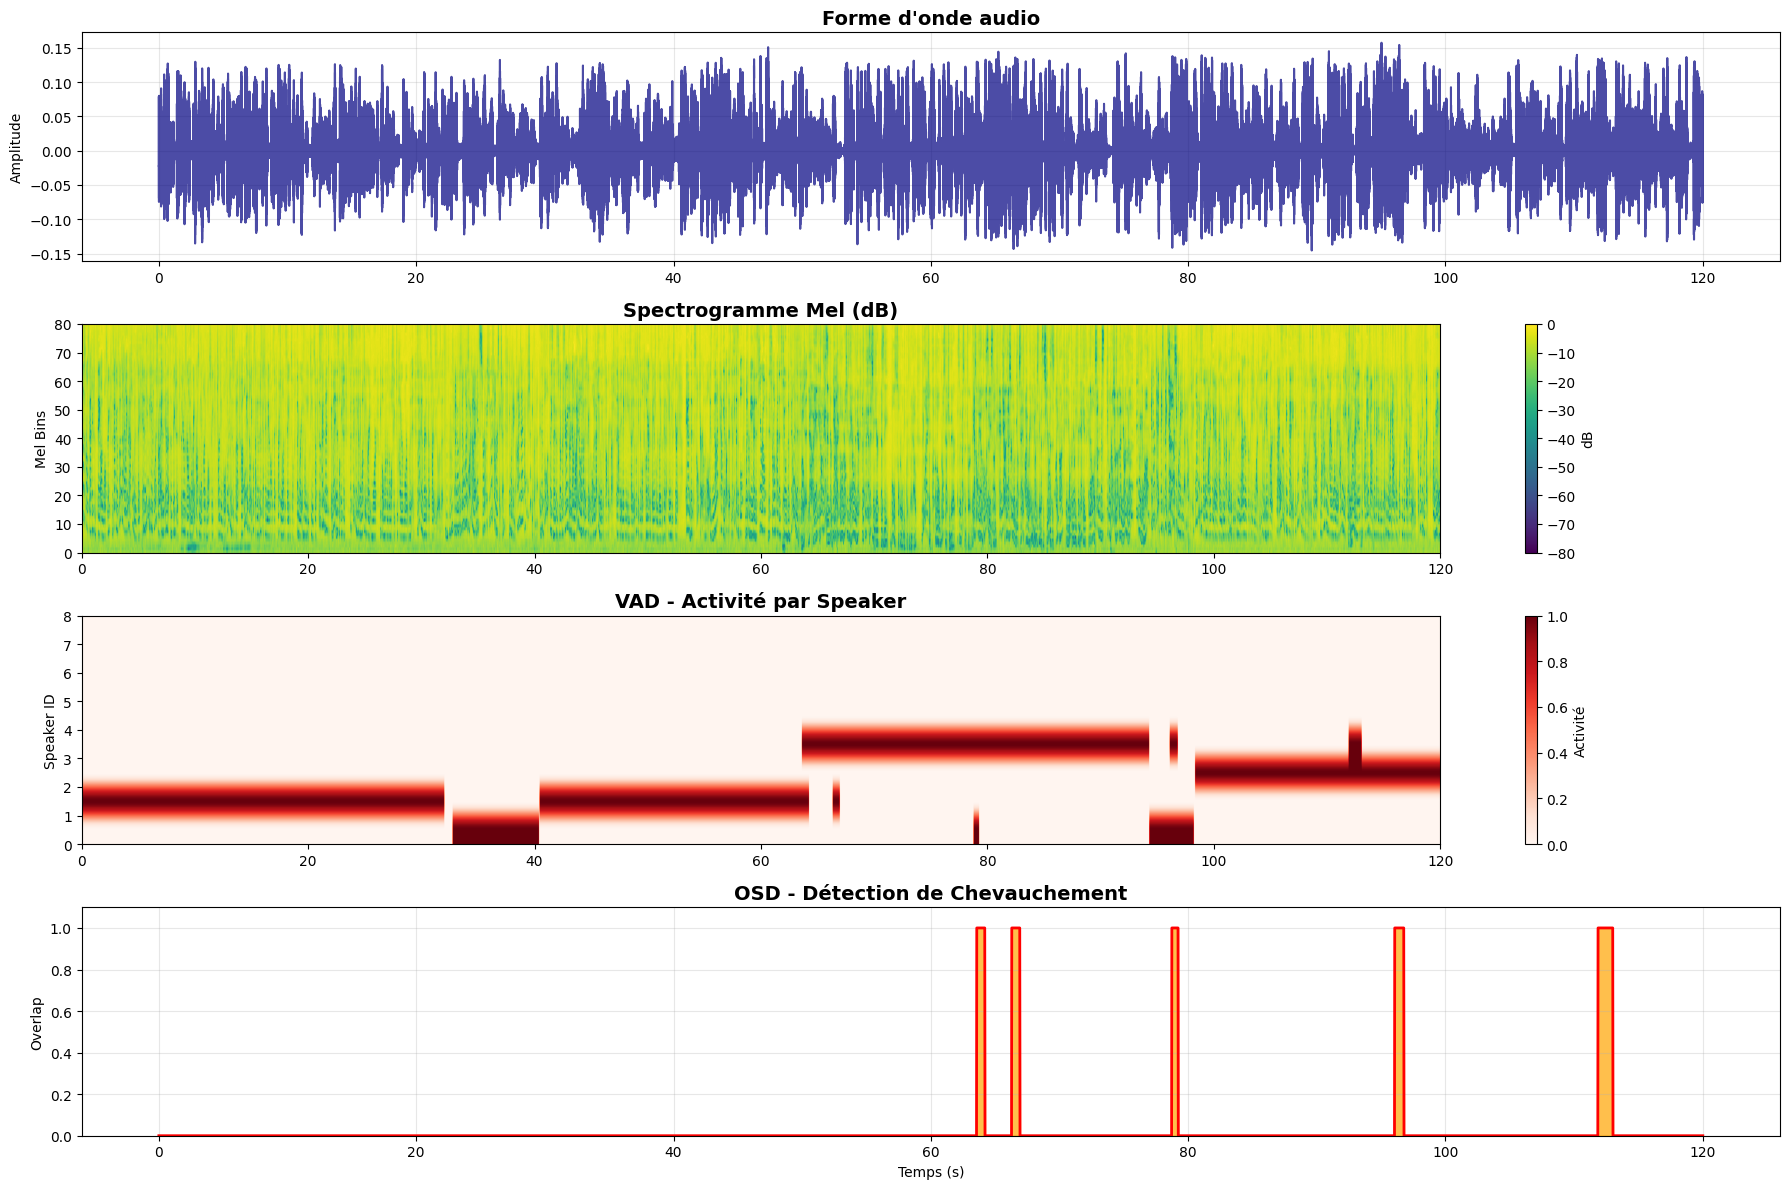

🔊 Lecteur audio interactif:



🎵 Segment 120.0s #3 (idx=2, score=11.3, 4 speakers, 3.1% overlap)
   Conversation: 0, Début: 4.0s, Durée: 120.0s
   Audio shape: (1920000,), Features shape: (80, 6000)
   Speakers actifs: [ 604. 2722. 1148. 1666.    0.    0.    0.    0.]
   Overlap frames: 183/6000 (3.0%)


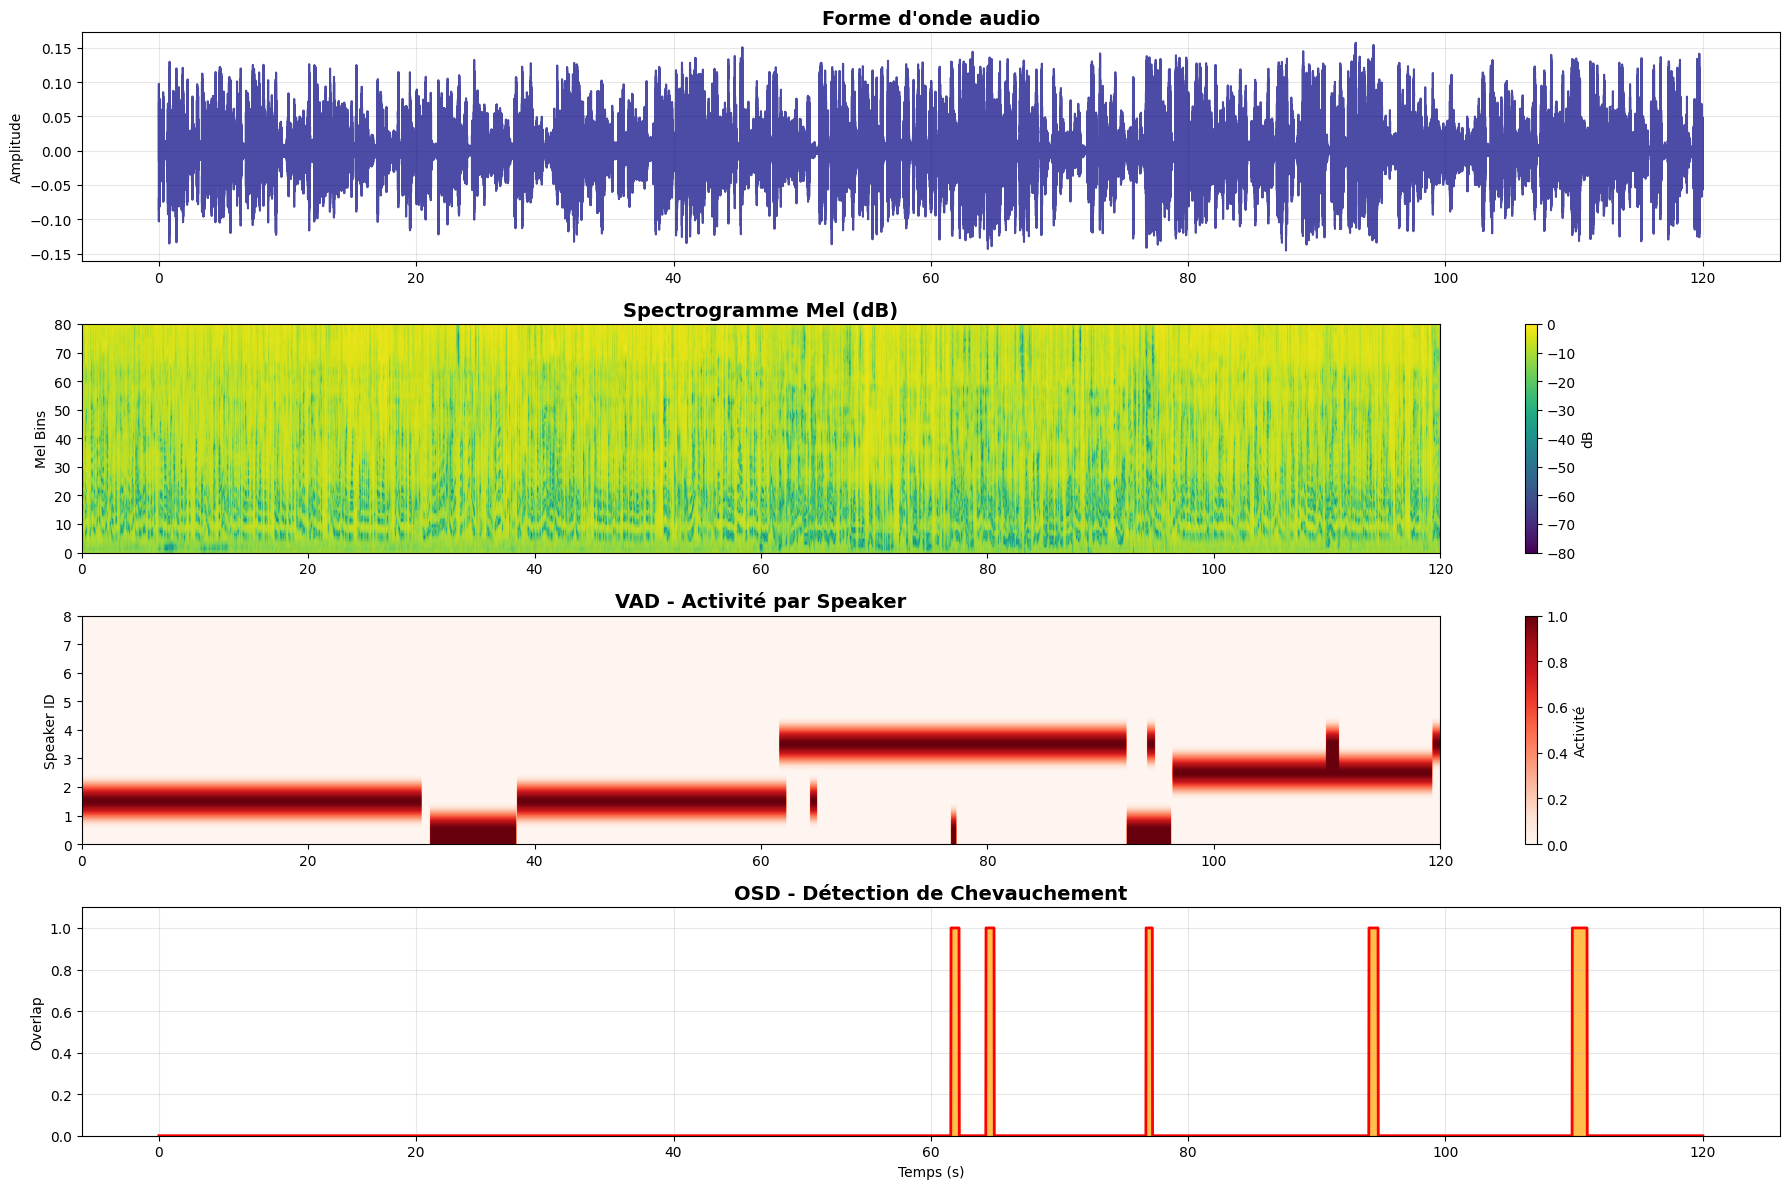

🔊 Lecteur audio interactif:


In [5]:
# Visualisation de tous les échantillons intéressants
for duration in CONFIGS['segment_durations']:
    print(f"\n{'='*80}")
    print(f"🎵 SEGMENTS {duration}s - ÉCHANTILLONS INTÉRESSANTS")
    print(f"{'='*80}")
    
    dataset = datasets[duration]
    samples = interesting_samples[duration]
    
    for sample_idx, (seg_idx, score, speakers, overlap) in enumerate(samples):
        title = f"Segment {duration}s #{sample_idx+1} (idx={seg_idx}, score={score:.1f}, {speakers} speakers, {overlap:.1%} overlap)"
        analyze_segment(dataset, seg_idx, title)

## Statistiques Comparatives

Comparaison des différentes durées de segments en termes de distribution des speakers et overlaps.

📊 STATISTIQUES COMPARATIVES:
  Duration  Avg_Speakers  Avg_Overlap  Avg_Activity  Total_Segments
0     4.0s          1.45        0.028         0.126           36205
1    10.0s          1.91        0.027         0.126           35557
2    60.0s          3.23        0.022         0.126           30240
3   120.0s          4.44        0.011         0.112           24409


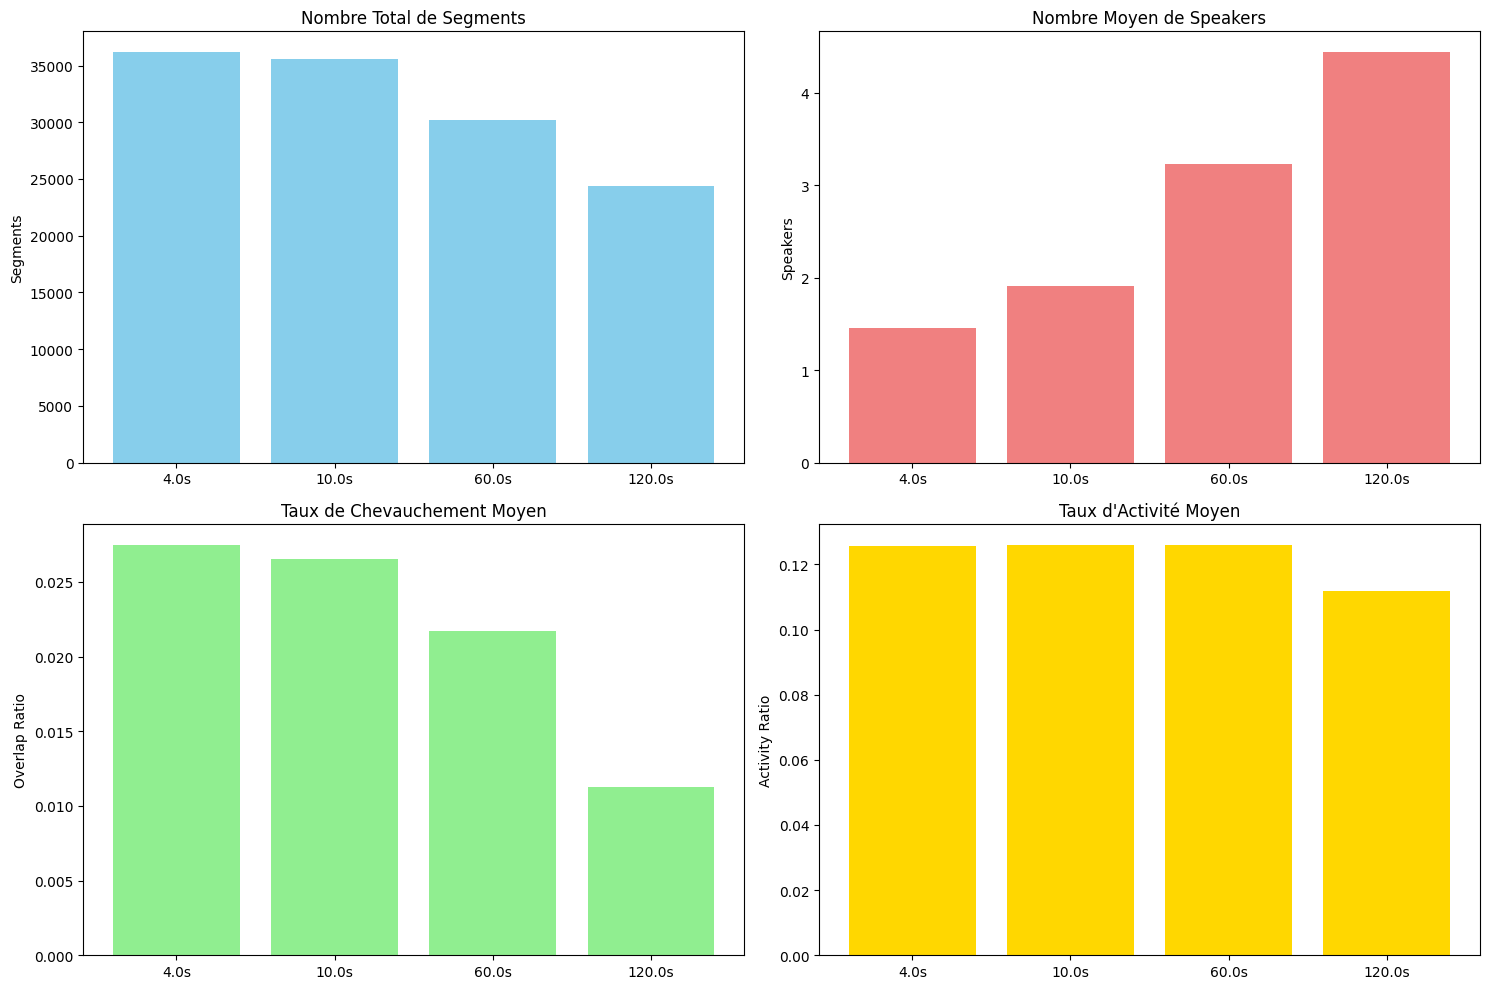

In [6]:
# Statistiques comparatives entre les durées
stats_data = []

for duration in CONFIGS['segment_durations']:
    dataset = datasets[duration]
    
    # Analyser un échantillon de segments pour les stats
    sample_size = min(100, len(dataset))
    total_speakers = []
    overlap_ratios = []
    activity_ratios = []
    
    for i in range(sample_size):
        sample = dataset[i]
        vad_labels = sample['vad_labels'].numpy()
        osd_labels = sample['osd_labels'].numpy()
        
        num_speakers = (vad_labels.sum(axis=0) > 0).sum()
        overlap_ratio = osd_labels.mean()
        activity_ratio = vad_labels.sum() / len(vad_labels) / CONFIGS['max_speakers']
        
        total_speakers.append(num_speakers)
        overlap_ratios.append(overlap_ratio)
        activity_ratios.append(activity_ratio)
    
    stats_data.append({
        'Duration': f"{duration}s",
        'Avg_Speakers': np.mean(total_speakers),
        'Avg_Overlap': np.mean(overlap_ratios),
        'Avg_Activity': np.mean(activity_ratios),
        'Total_Segments': len(dataset)
    })

# Créer DataFrame et afficher
stats_df = pd.DataFrame(stats_data)
print("📊 STATISTIQUES COMPARATIVES:")
print(stats_df.round(3))

# Graphique comparatif
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Nombre de segments
axes[0,0].bar(stats_df['Duration'], stats_df['Total_Segments'], color='skyblue')
axes[0,0].set_title('Nombre Total de Segments')
axes[0,0].set_ylabel('Segments')

# Speakers moyens
axes[0,1].bar(stats_df['Duration'], stats_df['Avg_Speakers'], color='lightcoral')
axes[0,1].set_title('Nombre Moyen de Speakers')
axes[0,1].set_ylabel('Speakers')

# Overlap moyen
axes[1,0].bar(stats_df['Duration'], stats_df['Avg_Overlap'], color='lightgreen')
axes[1,0].set_title('Taux de Chevauchement Moyen')
axes[1,0].set_ylabel('Overlap Ratio')

# Activité moyenne
axes[1,1].bar(stats_df['Duration'], stats_df['Avg_Activity'], color='gold')
axes[1,1].set_title('Taux d\'Activité Moyen')
axes[1,1].set_ylabel('Activity Ratio')

plt.tight_layout()
plt.show()